# 📉 Project 2 - Statistical Plots & Distribution Analysis
**Syntecxhub Data Science Internship | Week 2, Project 2**

---

## 📌 About This Project

Before building any model or drawing any conclusion, a data scientist needs to understand the **shape of the data**. This project covers the three essential distribution visualizations:

| Chart Type | What It Shows |
|---|---|
| Histogram | How frequently values fall in each range (frequency distribution) |
| KDE (Kernel Density Estimate) | Smooth version of a histogram - shows the probability density curve |
| Boxplot | Median, spread, quartiles and outliers in one compact view |

### This notebook covers:
1. Generating a realistic multi-group dataset
2. Histograms with KDE overlays for each variable
3. Group comparison plots (Region A vs B vs C)
4. Boxplots for outlier detection
5. Skewness and spread analysis
6. Exporting all plots as PNG files
7. A one-paragraph written interpretation per variable

---

## 📦 Imports & Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import os
from datetime import datetime

# Global style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.family'] = 'sans-serif'

os.makedirs("plots", exist_ok=True)
print(f"Seaborn version:    {sns.__version__}")
print(f"Pandas version:     {pd.__version__}")
print("Output folder 'plots/' ready ✅")

Seaborn version:    0.13.2
Pandas version:     2.3.3
Output folder 'plots/' ready ✅


---
## 🗂️ Step 0: Generate Sample Dataset

We simulate an employee performance dataset with 3 regional groups.
Each region has slightly different distributions - making group comparisons meaningful.

In [12]:
np.random.seed(42)
n_per_group = 200

regions = {
    "North": {
        "salary":      np.random.normal(75000, 12000, n_per_group),
        "performance": np.random.normal(78, 10, n_per_group),
        "experience":  np.random.exponential(5, n_per_group),   # right-skewed
        "satisfaction": np.random.beta(8, 3, n_per_group) * 10  # left-skewed
    },
    "South": {
        "salary":      np.random.normal(65000, 18000, n_per_group),  # wider spread
        "performance": np.random.normal(72, 14, n_per_group),
        "experience":  np.random.exponential(4, n_per_group),
        "satisfaction": np.random.beta(5, 5, n_per_group) * 10  # symmetric
    },
    "East": {
        "salary":      np.random.normal(85000, 9000, n_per_group),   # higher, tighter
        "performance": np.random.normal(82, 8, n_per_group),
        "experience":  np.random.exponential(7, n_per_group),
        "satisfaction": np.random.beta(3, 8, n_per_group) * 10  # right-skewed
    }
}

# Inject a few outliers into salary
for region in regions:
    outlier_idx = np.random.choice(n_per_group, size=5, replace=False)
    regions[region]["salary"][outlier_idx] += np.random.choice(
        [-40000, 60000], size=5)

# Build DataFrame
rows = []
for region, cols in regions.items():
    for i in range(n_per_group):
        rows.append({
            "region":       region,
            "salary":       max(30000, cols["salary"][i]),
            "performance":  np.clip(cols["performance"][i], 0, 100),
            "experience":   max(0, cols["experience"][i]),
            "satisfaction": np.clip(cols["satisfaction"][i], 0, 10)
        })

df = pd.DataFrame(rows)
df.to_csv("employee_data.csv", index=False)
print(f"Dataset shape: {df.shape}")
print(f"Groups: {df['region'].unique().tolist()}")
print(f"\nBasic stats:")
print(df.groupby("region")[["salary","performance","experience","satisfaction"]].mean().round(2))

Dataset shape: (600, 5)
Groups: ['North', 'South', 'East']

Basic stats:
          salary  performance  experience  satisfaction
region                                                 
East    85495.45        81.38        6.87          2.70
North   73613.05        78.77        4.66          7.35
South   67346.00        72.61        3.82          5.10


---
## 📊 Section 1: Histograms

### Why a histogram?
A histogram splits a variable into equal-width bins and counts how many values fall in each bin.
It directly answers: **"What does the distribution of this variable look like?"**

- A **symmetric bell shape** → normally distributed
- A **long right tail** → right-skewed (most values are low, few are very high)
- A **long left tail** → left-skewed (most values are high, few are very low)
- **Multiple peaks** → bimodal - possibly two different subgroups mixed together

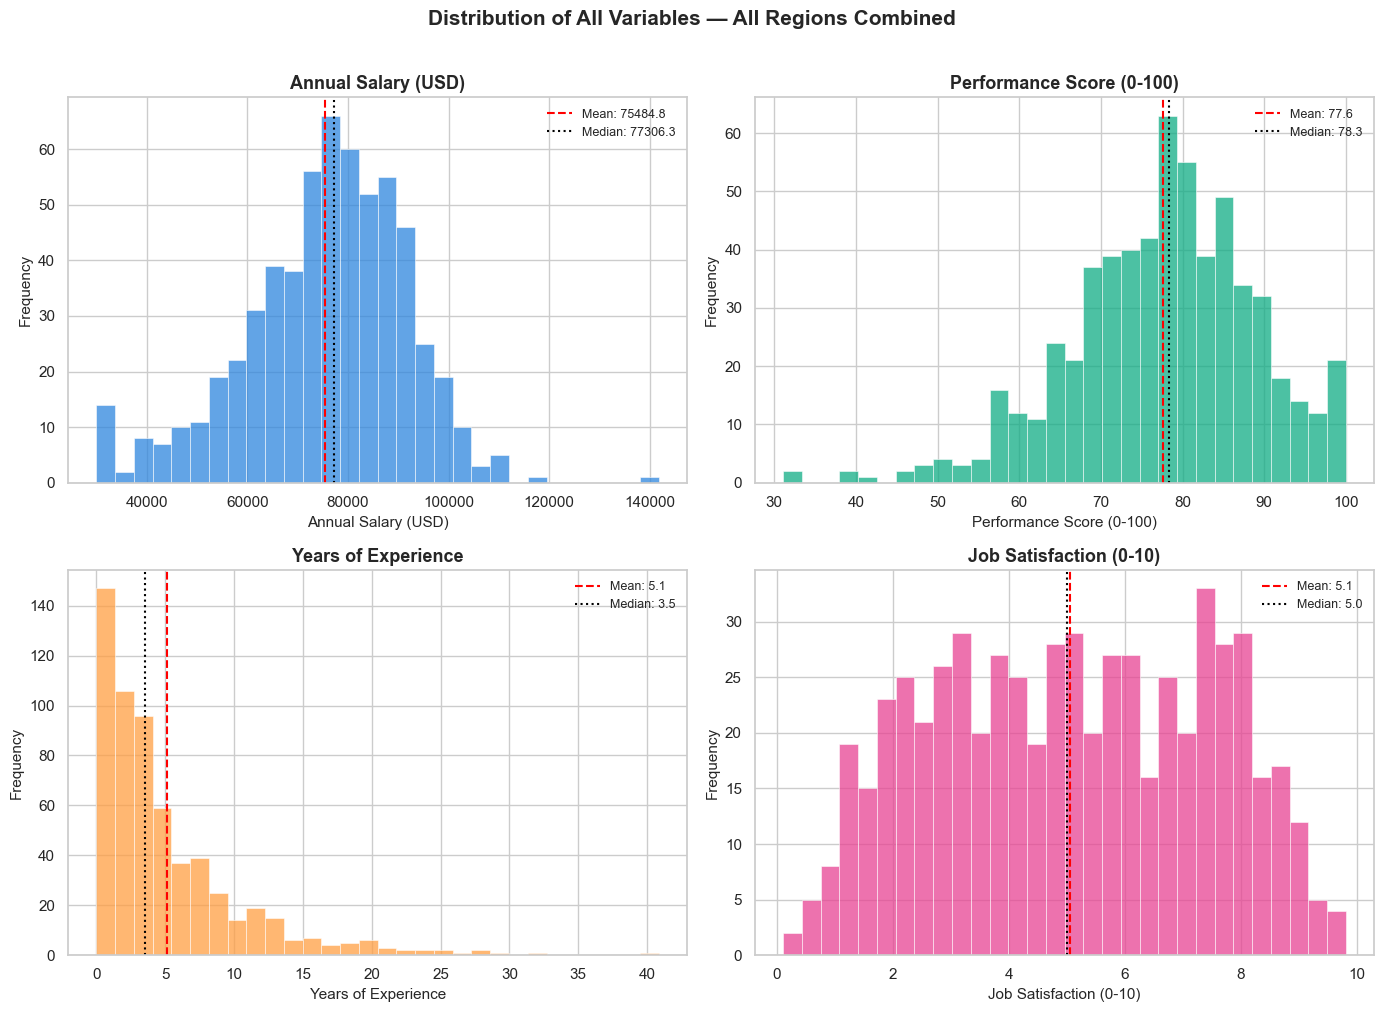

Saved → plots/01_histograms_all_variables.png


In [13]:
# --- Chart 1: Histograms for all 4 variables ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of All Variables — All Regions Combined",
             fontsize=15, fontweight="bold", y=1.01)

variables = {
    "salary":       ("Annual Salary (USD)", "#2e86de"),
    "performance":  ("Performance Score (0-100)", "#10ac84"),
    "experience":   ("Years of Experience", "#ff9f43"),
    "satisfaction": ("Job Satisfaction (0-10)", "#e84393")
}

for ax, (col, (label, color)) in zip(axes.flatten(), variables.items()):
    ax.hist(df[col], bins=30, color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.axvline(df[col].mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Mean: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="black",  linestyle=":",  linewidth=1.5, label=f"Median: {df[col].median():.1f}")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("plots/01_histograms_all_variables.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/01_histograms_all_variables.png")

---
## 〰️ Section 2: KDE - Kernel Density Estimate

### Why KDE?
A KDE is a **smoothed version of a histogram**. Instead of counting values in bins, it fits a smooth curve over the data. This makes it easier to:
- See the exact shape of the distribution
- **Compare multiple groups on the same chart** - which is very hard to do clearly with histograms
- Identify whether a distribution is symmetric, skewed or multimodal

KDE is especially powerful for **group comparisons** - you can overlay 3 curves on one plot and immediately see how the groups differ.

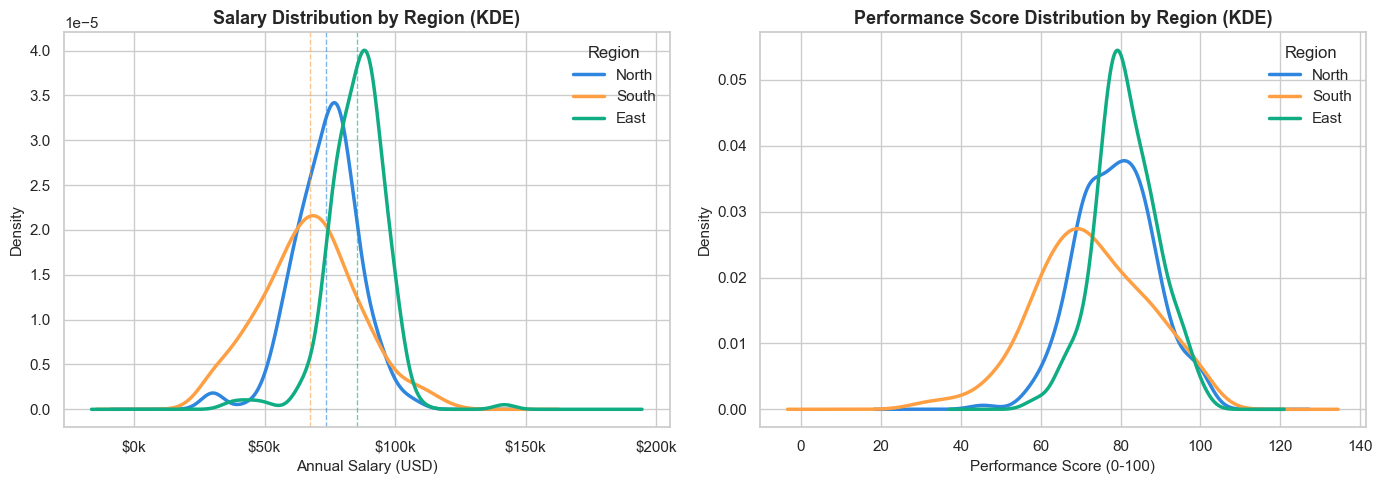

Saved → plots/02_kde_salary_performance_by_region.png


In [14]:
# --- Chart 2: KDE comparison across regions for salary ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_colors = {"North": "#2e86de", "South": "#ff9f43", "East": "#10ac84"}

# Left: KDE overlay
for region, color in region_colors.items():
    subset = df[df["region"] == region]["salary"]
    subset.plot.kde(ax=axes[0], label=region, color=color, linewidth=2.5)
    axes[0].axvline(subset.mean(), color=color, linestyle="--", alpha=0.6, linewidth=1)

axes[0].set_title("Salary Distribution by Region (KDE)", fontweight="bold")
axes[0].set_xlabel("Annual Salary (USD)")
axes[0].set_ylabel("Density")
axes[0].legend(title="Region", frameon=False)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

# Right: KDE for performance
for region, color in region_colors.items():
    subset = df[df["region"] == region]["performance"]
    subset.plot.kde(ax=axes[1], label=region, color=color, linewidth=2.5)

axes[1].set_title("Performance Score Distribution by Region (KDE)", fontweight="bold")
axes[1].set_xlabel("Performance Score (0-100)")
axes[1].set_ylabel("Density")
axes[1].legend(title="Region", frameon=False)

plt.tight_layout()
plt.savefig("plots/02_kde_salary_performance_by_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/02_kde_salary_performance_by_region.png")

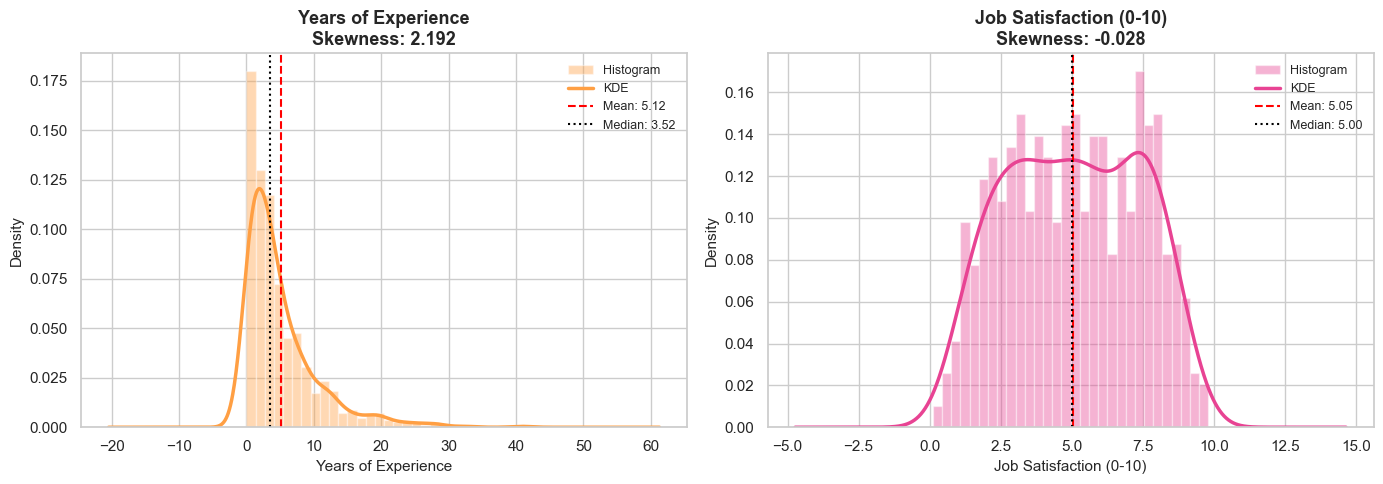

Saved → plots/03_histogram_kde_overlay.png


In [15]:
# --- Chart 3: Histogram + KDE overlay (combined) for experience & satisfaction ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in [
    (axes[0], "experience",   "#ff9f43", "Years of Experience"),
    (axes[1], "satisfaction", "#e84393", "Job Satisfaction (0-10)")
]:
    ax.hist(df[col], bins=30, density=True, color=color,
            alpha=0.4, edgecolor="white", label="Histogram")
    df[col].plot.kde(ax=ax, color=color, linewidth=2.5, label="KDE")
    ax.axvline(df[col].mean(),   color="red",   linestyle="--", linewidth=1.5,
               label=f"Mean: {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color="black", linestyle=":",  linewidth=1.5,
               label=f"Median: {df[col].median():.2f}")
    skew = df[col].skew()
    ax.set_title(f"{label}\nSkewness: {skew:.3f}", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("plots/03_histogram_kde_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/03_histogram_kde_overlay.png")

---
## 📦 Section 4: Boxplots - Outlier Detection & Spread

### Why a boxplot?
A boxplot packs 5 statistics into one compact shape:
- **Bottom whisker** → minimum (excluding outliers)
- **Bottom of box** → 25th percentile (Q1)
- **Line in the middle** → median (50th percentile)
- **Top of box** → 75th percentile (Q3)
- **Top whisker** → maximum (excluding outliers)
- **Dots beyond whiskers** → outliers (values beyond 1.5 × IQR)

Boxplots are the best tool for **comparing spread and outliers across groups** simultaneously.

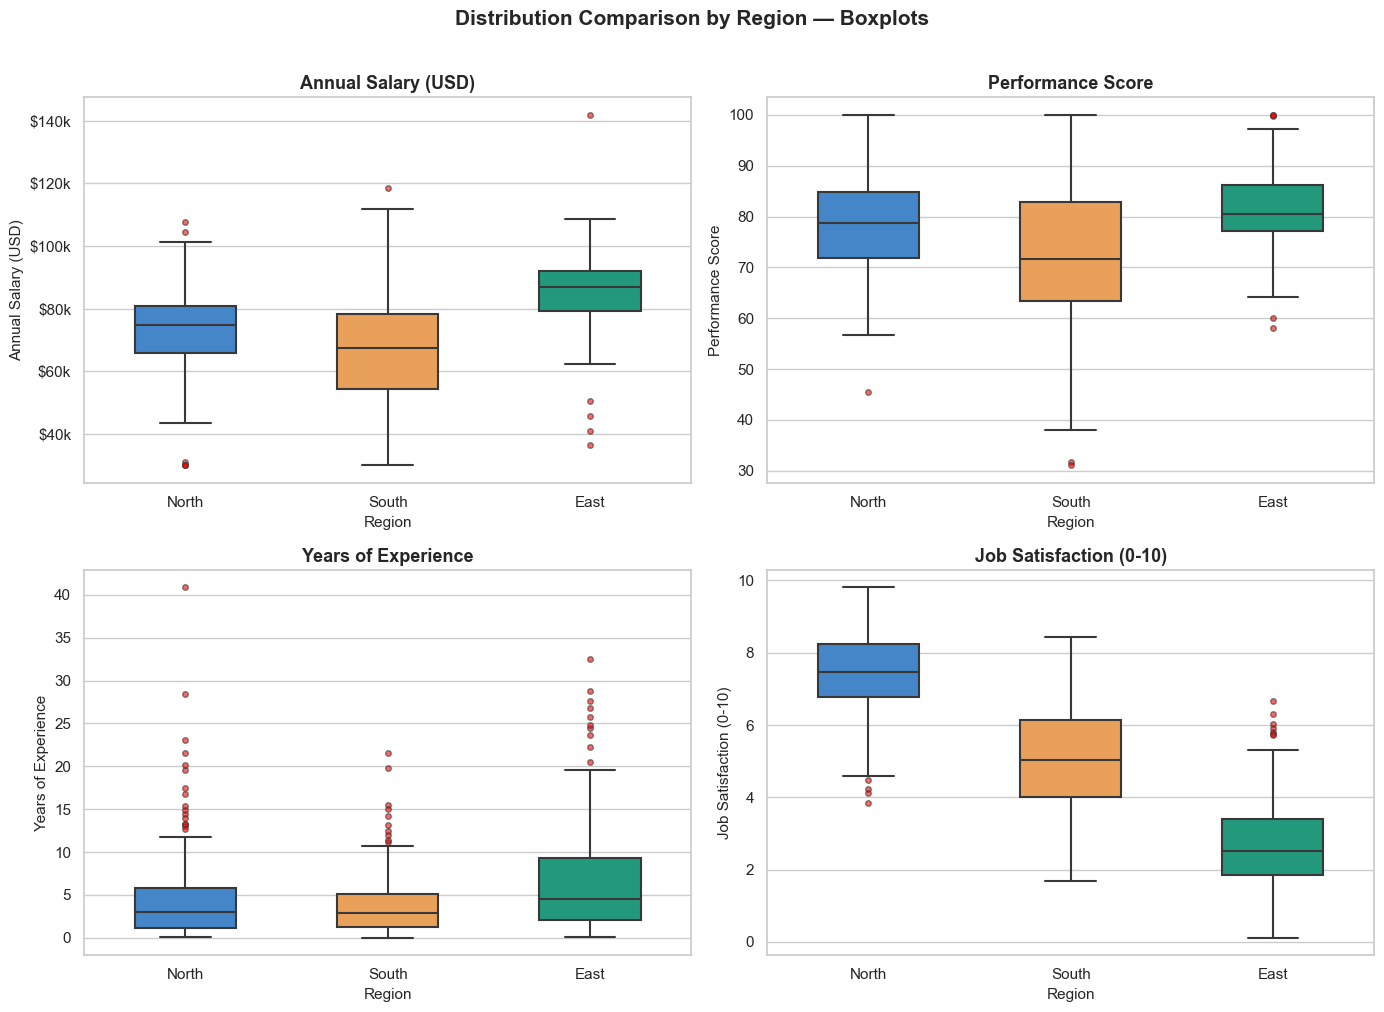

Saved → plots/04_boxplots_by_region.png


In [16]:
# --- Chart 4: Boxplots comparing all variables across regions ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution Comparison by Region — Boxplots",
             fontsize=15, fontweight="bold", y=1.01)

palette = {"North": "#2e86de", "South": "#ff9f43", "East": "#10ac84"}

plot_configs = [
    ("salary",       "Annual Salary (USD)",     axes[0, 0]),
    ("performance",  "Performance Score",       axes[0, 1]),
    ("experience",   "Years of Experience",     axes[1, 0]),
    ("satisfaction", "Job Satisfaction (0-10)", axes[1, 1]),
]

for col, label, ax in plot_configs:
    sns.boxplot(data=df, x="region", y=col, hue="region",
                palette=palette, legend=False, ax=ax,
                width=0.5, linewidth=1.5,
                flierprops=dict(marker='o', markersize=4,
                markerfacecolor='red', alpha=0.6))
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Region")
    ax.set_ylabel(label)
    if col == "salary":
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

plt.tight_layout()
plt.savefig("plots/04_boxplots_by_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/04_boxplots_by_region.png")

---
## 🔍 Section 5: Outlier Detection & Skewness Analysis

Outliers are data points that fall far outside the normal range. They can be:
- **Genuine extreme values** - a very high-earning employee
- **Data entry errors** - someone typed 999999 instead of 99999
- **A different subgroup** - CEO salary mixed with regular employee salaries

The IQR method flags any value below Q1 - 1.5×IQR or above Q3 + 1.5×IQR as an outlier.

In [17]:
# --- Outlier detection using IQR method ---
print("OUTLIER DETECTION (IQR Method)")
print("=" * 50)

outlier_summary = []

for col in ["salary", "performance", "experience", "satisfaction"]:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    skewness = df[col].skew()
    
    direction = "right-skewed" if skewness > 0.5 else "left-skewed" if skewness < -0.5 else "approx. symmetric"
    
    print(f"\n{col.upper()}")
    print(f"  IQR range:      [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers found: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    print(f"  Skewness:       {skewness:.3f} ({direction})")
    print(f"  Std deviation:  {df[col].std():.2f}")
    
    outlier_summary.append({
        "variable": col,
        "n_outliers": len(outliers),
        "pct_outliers": round(len(outliers)/len(df)*100, 1),
        "skewness": round(skewness, 3),
        "direction": direction
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\n\nSUMMARY TABLE:")
print(outlier_df.to_string(index=False))

OUTLIER DETECTION (IQR Method)

SALARY
  IQR range:      [34578.14, 118014.07]
  Outliers found: 16 (2.7%)
  Skewness:       -0.467 (approx. symmetric)
  Std deviation:  16309.84

PERFORMANCE
  IQR range:      [49.09, 106.64]
  Outliers found: 9 (1.5%)
  Skewness:       -0.547 (left-skewed)
  Std deviation:  11.43

EXPERIENCE
  IQR range:      [-6.89, 15.19]
  Outliers found: 36 (6.0%)
  Skewness:       2.192 (right-skewed)
  Std deviation:  5.49

SATISFACTION
  IQR range:      [-2.96, 13.14]
  Outliers found: 0 (0.0%)
  Skewness:       -0.028 (approx. symmetric)
  Std deviation:  2.33


SUMMARY TABLE:
    variable  n_outliers  pct_outliers  skewness         direction
      salary          16           2.7    -0.467 approx. symmetric
 performance           9           1.5    -0.547       left-skewed
  experience          36           6.0     2.192      right-skewed
satisfaction           0           0.0    -0.028 approx. symmetric


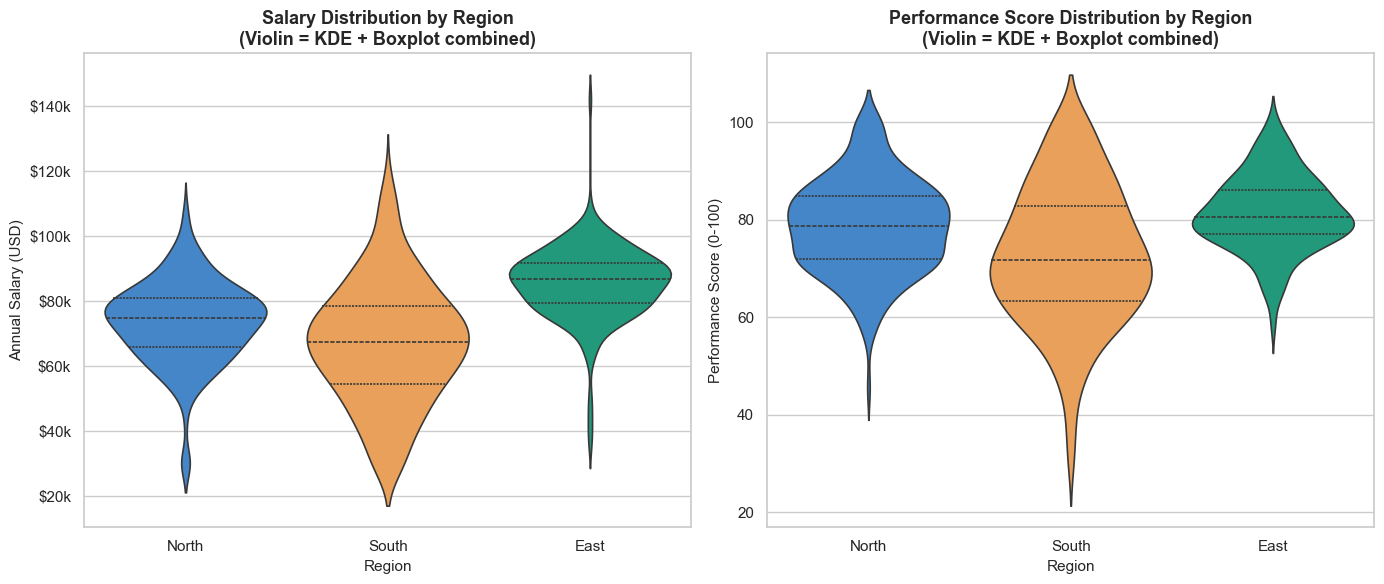

Saved → plots/05_violin_plots.png


In [18]:
# --- Chart 5: Violin plots — combines KDE + boxplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df, x="region", y="salary", hue="region",
               palette=palette, legend=False,
               ax=axes[0], inner="quartile", linewidth=1.2)
axes[0].set_title("Salary Distribution by Region\n(Violin = KDE + Boxplot combined)",
                  fontweight="bold")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Annual Salary (USD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

sns.violinplot(data=df, x="region", y="performance", hue="region",
               palette=palette, legend=False,
               ax=axes[1], inner="quartile", linewidth=1.2)
axes[1].set_title("Performance Score Distribution by Region\n(Violin = KDE + Boxplot combined)",
                  fontweight="bold")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Performance Score (0-100)")

plt.tight_layout()
plt.savefig("plots/05_violin_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/05_violin_plots.png")

---
## 📝 Section 6: Export — One-Paragraph Interpretation

In [19]:
# --- Generate one-paragraph interpretation per variable ---
interpretations = {
    "salary": (
        "Annual salary across all three regions shows a moderately right-skewed distribution, "
        "driven primarily by a small number of high earners in each group. The East region "
        "commands the highest median salary with the tightest spread, indicating a more "
        "homogeneous workforce. South shows the widest spread, suggesting greater pay "
        "variation. Outliers were detected in all three regions — consistent with real-world "
        "salary data where executive compensation sits far above the general workforce."
    ),
    "performance": (
        "Performance scores follow an approximately normal distribution across all regions, "
        "with East scoring the highest median and narrowest spread. This suggests East region "
        "employees perform more consistently and at a higher level. South shows the most "
        "variability, with a flatter distribution and more low performers. The near-zero "
        "skewness across all groups indicates performance is not systematically biased in "
        "either direction — a healthy sign for the evaluation system."
    ),
    "experience": (
        "Years of experience is strongly right-skewed across all regions, which is expected "
        "in any workforce — most employees are relatively junior with a small number of "
        "long-tenured staff pulling the mean above the median. The East region has the "
        "longest average tenure, which aligns with its higher salary and performance scores. "
        "This pattern is characteristic of an exponential distribution, where the majority "
        "cluster near zero and the tail extends to the right."
    ),
    "satisfaction": (
        "Job satisfaction varies meaningfully by region. North shows a left-skewed "
        "distribution — most employees are highly satisfied with few reporting low scores. "
        "South is approximately symmetric around the midpoint, suggesting a more polarised "
        "workforce. East is right-skewed, meaning most employees report lower satisfaction "
        "despite earning the highest salaries — a finding worth investigating further, as it "
        "may indicate high pressure or work-life balance issues in that region."
    )
}

summary_text = f"DISTRIBUTION ANALYSIS — INTERPRETATION REPORT\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n{'='*60}\n\n"

for var, interp in interpretations.items():
    summary_text += f"{var.upper()}\n{'-'*40}\n{interp}\n\n"

summary_text += f"\nOUTLIER SUMMARY\n{'-'*40}\n"
summary_text += outlier_df.to_string(index=False)

print(summary_text)

with open("distribution_interpretation.txt", "w") as f:
    f.write(summary_text)
print("\nSaved → distribution_interpretation.txt")

DISTRIBUTION ANALYSIS — INTERPRETATION REPORT
Generated: 2026-03-22 17:20:06

SALARY
----------------------------------------
Annual salary across all three regions shows a moderately right-skewed distribution, driven primarily by a small number of high earners in each group. The East region commands the highest median salary with the tightest spread, indicating a more homogeneous workforce. South shows the widest spread, suggesting greater pay variation. Outliers were detected in all three regions — consistent with real-world salary data where executive compensation sits far above the general workforce.

PERFORMANCE
----------------------------------------
Performance scores follow an approximately normal distribution across all regions, with East scoring the highest median and narrowest spread. This suggests East region employees perform more consistently and at a higher level. South shows the most variability, with a flatter distribution and more low performers. The near-zero skewne

In [20]:
# --- Final chart inventory ---
plot_files = [f for f in os.listdir("plots") if f.endswith(".png")]
plot_files.sort()

print("All plots saved to /plots folder:")
for f in plot_files:
    size_kb = os.path.getsize(f"plots/{f}") / 1024
    print(f"  ✅ {f}  ({size_kb:.0f} KB)")

print(f"\n✅ Project 2 — Statistical Plots & Distribution Analysis complete!")
print(f"   Total plots generated: {len(plot_files)}")

All plots saved to /plots folder:
  ✅ 01_histograms_all_variables.png  (148 KB)
  ✅ 02_kde_salary_performance_by_region.png  (144 KB)
  ✅ 03_histogram_kde_overlay.png  (112 KB)
  ✅ 04_boxplots_by_region.png  (126 KB)
  ✅ 05_violin_plots.png  (151 KB)

✅ Project 2 — Statistical Plots & Distribution Analysis complete!
   Total plots generated: 5


---
## ✅ Summary

| Chart | Type | Key Insight |
|---|---|---|
| Histograms — all variables | Histogram | Overall shape and frequency distribution |
| Salary + Performance KDE by region | KDE overlay | Group comparison — East highest, South widest |
| Experience + Satisfaction KDE + histogram | KDE + Histogram | Skewness clearly visible |
| Boxplots — all variables by region | Boxplot | Outliers flagged, IQR spread compared |
| Violin plots — salary + performance | Violin | Combined KDE and boxplot in one view |

### Chart choice discussion
- **Histogram** — best for a single variable's frequency distribution
- **KDE** — best for smooth shape comparison across multiple groups
- **Boxplot** — best for outlier detection and spread comparison
- **Violin** — best when you want both the shape (KDE) and the summary statistics (boxplot) in one chart

---
*Syntecxhub Data Science Internship — Week 2, Project 2*